# Generating embeddings from a self-supervised speech model

## Preliminaries

First we import the libraries

In [1]:
# standard libraries for data science
import pandas as pd
import numpy as np
from pathlib import Path
import random

# specialized libraries for audio and .wav processing
import phonlab as pb
import librosa

# tools to convert directories to dataframes
import fileorganize

# progress bars
from tqdm import tqdm

# machine learning packages
from transformers import AutoFeatureExtractor, AutoModel
import torch

# tools for our visualization
from sklearn.decomposition import PCA
import seaborn as sns

Next we store the path to our data directory.

In [2]:
# set constant
DATA_DIR=Path("AudioMNIST_data")

Finally, we'll check if a GPU is available to speed up the computation.

In [3]:
# automatically select the best hardware accelerator if available, otherwise fallback to CPU
device = torch.device(torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## Data loading

Let's create a DataFrame of files in our data directory and select 500 random recordings for our use in this tutorial.

In [4]:
dir_df = fileorganize.dir_to_df(DATA_DIR)
dir_df = (pd.concat([dir_df, dir_df['fname']
    .str.extract(r"^(?P<digit>\d+)_(?P<speaker>\d+)_(?P<token>\d+).wav")], axis='columns')
    .sample(n=500, random_state=77)
    .reset_index(drop=True))

The following code displays the first five rows of the DataFrame

In [5]:
dir_df.head()

,relpath,fname,digit,speaker,token
0,08,3_08_28.wav,3,08,28
1,51,8_51_26.wav,8,51,26
2,08,7_08_37.wav,7,08,37
3,31,1_31_48.wav,1,31,48
4,48,7_48_26.wav,7,48,26


## Modeling one audio file

Let's process a single file before we do them all.
We'll save the first file in the DataFrame to a standalone variable.

In [6]:
relpath, fname, digit, speaker, token = dir_df.loc[0, :]

Next we can configure the model.

In [7]:
MODEL = "microsoft/wavlm-base"
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL)
model = AutoModel.from_pretrained(MODEL).to(device).eval()

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

### Load the audio

We'll load and resample the audio at the same time using the `phonlab` package.

In [8]:
# model requires 16000Hz sampling rate
target_sr = 16000

# acquire filepath to wav file
fpath = DATA_DIR / relpath / fname

# load audio and sampling rate (for confirmation)
audio_array, sampling_rate = pb.loadsig(fpath, fs=target_sr) 


### Run the audio through the model

This cell actually generates the embeddings.

In [9]:
# create inputs
inputs = feature_extractor(audio_array, sampling_rate = sampling_rate, return_tensors = "pt")

# move inputs to chip
inputs = {k: v.to(device) for k, v in inputs.items()}

# run model to generate outputs
with torch.inference_mode():
    outputs = model(**inputs, output_hidden_states = True)


/Users/noah/Desktop/project_support/dlab/blog_1/.venv/lib/python3.13/site-packages/torch/nn/functional.py:6829: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


### Inspect the output

Now we can take a look at our embeddings.

In [10]:
# number of layers
outputs.hidden_states

(tensor([[[-0.2460, -0.3713,  0.2699,  ...,  0.1935,  0.0100,  0.0346],
          [ 0.0082,  0.0904,  0.1547,  ..., -0.1370,  0.0291,  0.1263],
          [ 0.0126, -0.2226,  0.3095,  ..., -0.2791, -0.1127, -0.0038],
          ...,
          [-0.0985, -0.0377, -0.1808,  ..., -0.0441,  0.1776, -0.0290],
          [ 0.2495, -0.0717,  0.1072,  ...,  0.0420,  0.2116,  0.1097],
          [-0.0806, -0.3133,  0.1259,  ..., -0.1778, -0.0869,  0.2096]]],
        device='mps:0'),
 tensor([[[ 0.0121,  0.1002,  0.0389,  ...,  0.0617, -0.0780, -0.0815],
          [ 0.0518,  0.0771,  0.0374,  ..., -0.0078, -0.1219, -0.0283],
          [ 0.0417,  0.0860,  0.0780,  ..., -0.0595, -0.1018,  0.0726],
          ...,
          [ 0.1081,  0.1671, -0.0045,  ...,  0.0618,  0.0558, -0.0394],
          [ 0.1755,  0.1095,  0.0505,  ...,  0.1466,  0.0210, -0.0917],
          [ 0.0839,  0.0022, -0.0050,  ...,  0.0689, -0.0815,  0.0422]]],
        device='mps:0'),
 tensor([[[-0.0248, -0.0259,  0.0735,  ...,  0.0193,

In [11]:
# shape of output
outputs.hidden_states[-1].shape

torch.Size([1, 24, 768])

## Modeling many audio files

Now we can generate embeddings for the whole set of files. 
As a first step, we wrap part of the above workflow in a function.

In [12]:
def extract_features(audio_array, audio_sr, layer_idx):
    # create inputs
    inputs = feature_extractor(audio_array, sampling_rate = audio_sr, return_tensors = "pt")

    # move inputs to chip
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # run model to generate outputs
    with torch.inference_mode():
        outputs = model(**inputs, output_hidden_states = True)

    # extract a specific layer
    layer_features = outputs.hidden_states[layer_idx] 

    return layer_features.squeeze(0).cpu().numpy()

Next we loop over the DataFrame to apply the function, collecting the relevant information as we go.

In [13]:
embedding_df = []
for idx, relpath, fname, digit, speaker, token in tqdm(dir_df.itertuples(), total=len(dir_df)):
    target_sr = 16000
    fpath = DATA_DIR / relpath / fname

    audio_array, sampling_rate = pb.loadsig(fpath, fs=target_sr)

    embedding = extract_features(audio_array, sampling_rate, -1)
    embedding_df.append({
        "audio_arr": audio_array,
        "sampling_rate": sampling_rate,
        "embedding": embedding,
    })

100%|████████████████████████████████████████████████████████████████| 500/500 [00:30<00:00, 16.61it/s]


And we add it to our DataFrame.

In [14]:
df = pd.concat([dir_df, pd.DataFrame(embedding_df)], axis='columns')

Which now looks as follows

In [15]:
df.head()

,relpath,fname,digit,speaker,token,audio_arr,sampling_rate,embedding
0,08,3_08_28.wav,3,08,28,"[-7.966166e-05, -8.492012e-05, -1.9116676e-05,...",16000,"[[0.06620152, -0.29590702, -0.40400973, 0.3096..."
1,51,8_51_26.wav,8,51,26,"[-0.000494209, -0.0008045644, -0.000676851, -0...",16000,"[[-0.34591427, -0.04296931, -0.6993937, 0.4948..."
2,08,7_08_37.wav,7,08,37,"[0.0001499454, 0.00024229518, 0.00022223865, 0...",16000,"[[0.038665857, -0.20632038, -0.37230194, 0.272..."
3,31,1_31_48.wav,1,31,48,"[-7.088158e-05, -6.9396294e-05, -3.7997946e-05...",16000,"[[-0.31407362, 0.13861626, -0.32352996, 0.2302..."
4,48,7_48_26.wav,7,48,26,"[-0.00012433727, -0.0002010742, -0.00019790189...",16000,"[[0.008114325, -0.14528684, -0.6209556, 0.3154..."


## Visualizing the embeddings

First we write the statpool function, apply it to our embeddings, and add the results to the DataFrame.

In [16]:
def statpool(x: np.ndarray) -> np.ndarray:
    assert x.ndim == 2 
    means = x.mean(axis=0)
    sds = x.std(axis=0) + 1e-5
    return np.concat([means, sds])

df['statpool'] = df['embedding'].map(statpool)
df.head()

,relpath,fname,digit,speaker,token,audio_arr,sampling_rate,embedding,statpool
0,08,3_08_28.wav,3,08,28,"[-7.966166e-05, -8.492012e-05, -1.9116676e-05,...",16000,"[[0.06620152, -0.29590702, -0.40400973, 0.3096...","[-0.13731727, -0.17425092, -0.2902805, -0.0393..."
1,51,8_51_26.wav,8,51,26,"[-0.000494209, -0.0008045644, -0.000676851, -0...",16000,"[[-0.34591427, -0.04296931, -0.6993937, 0.4948...","[-0.16260774, -0.20700438, -0.36837438, -0.063..."
2,08,7_08_37.wav,7,08,37,"[0.0001499454, 0.00024229518, 0.00022223865, 0...",16000,"[[0.038665857, -0.20632038, -0.37230194, 0.272...","[0.010222868, -0.0058908616, -0.21800701, 0.02..."
3,31,1_31_48.wav,1,31,48,"[-7.088158e-05, -6.9396294e-05, -3.7997946e-05...",16000,"[[-0.31407362, 0.13861626, -0.32352996, 0.2302...","[0.117867544, 0.11935952, -0.4063009, 0.049537..."
4,48,7_48_26.wav,7,48,26,"[-0.00012433727, -0.0002010742, -0.00019790189...",16000,"[[0.008114325, -0.14528684, -0.6209556, 0.3154...","[-0.025183553, 0.019675966, -0.33645526, 0.079..."


We'll use PCA to reduce the dimensions.

In [17]:
df[["x_coord", "y_coord", "z_coord"]] = PCA(n_components=3).fit_transform(np.stack(df['statpool']))

Now we'll plot the first two dimensions using Seaborn.

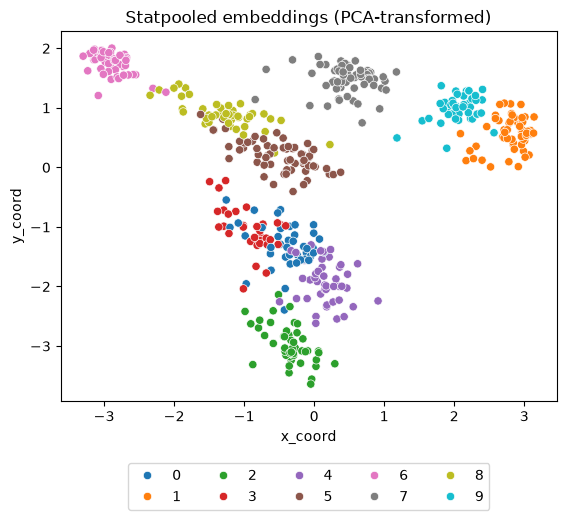

In [18]:
ax = sns.scatterplot(data=df, x="x_coord", y="y_coord", hue="digit", hue_order=[str(i) for i in range(0,10)])
ax.set_title("Statpooled embeddings (PCA-transformed)")
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.15), ncol=5, title=None)

We can compare these embeddings to MFCCs, another common way of featurizing speech.

In [19]:
mfccs_statpooled = []

for idx, audio_arr, sampling_rate in df[['audio_arr', 'sampling_rate']].itertuples():
    mfccs = librosa.feature.mfcc(y=audio_arr, sr=sampling_rate, n_mfcc=20).T
    mfccs_statpooled.append(statpool(mfccs))

mfcc_features = np.stack(mfccs_statpooled)
mfcc_coords = PCA(n_components=3).fit_transform(mfcc_features)
mfcc_df = df[["digit"]]
mfcc_df[["x_coord", "y_coord", "z_coord"]] = mfcc_coords

This code generates the MFCC plot.

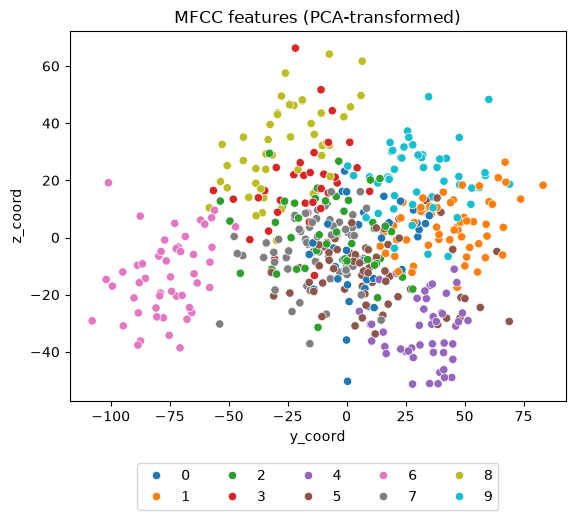

In [20]:
ax = sns.scatterplot(data=mfcc_df, x="y_coord", y="z_coord", hue="digit", hue_order=[str(i) for i in range(0,10)])
ax.set_title("MFCC features (PCA-transformed)")
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.15), ncol=5, title=None)